In [1]:
import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

import numpy as np
import matplotlib.pyplot as plt
import functions
import bilby
import seaborn as sns
import pandas as pd
from pprint import pprint

In [2]:
sns.set_theme(context="talk", palette="husl", style="whitegrid")
palette = sns.color_palette("husl")

In [3]:
# ---------------------------
# Priors
# ---------------------------
priors = bilby.core.prior.PriorDict()
priors['mass_1'] = bilby.core.prior.analytical.PowerLaw(minimum=5, maximum=50, alpha=-2.3,
                                                        name='mass_1')
priors['a_1'] = bilby.core.prior.Uniform(name='a_1', minimum=0, maximum=0.1)
priors['tilt_1'] = bilby.core.prior.analytical.Sine(name='tilt_1')
priors['tilt_2'] = bilby.core.prior.analytical.Sine(name='tilt_2')
priors['phi_12'] = bilby.core.prior.Uniform(name='phi_12', minimum=0,
                                            maximum=2 * np.pi, boundary='periodic')
priors['phi_jl'] = bilby.core.prior.Uniform(name='phi_jl', minimum=0,
                                            maximum=2 * np.pi, boundary='periodic')
priors['phase'] = bilby.core.prior.Uniform(name='phase', minimum=0,
                                           maximum=2 * np.pi, boundary='periodic')
priors['theta_jn'] = bilby.core.prior.analytical.Sine(minimum=75 / 180 * np.pi,
                                                      maximum=105 / 180 * np.pi,
                                                      name='theta_jn')
print("Priors used for 1G population:")
pprint(priors)

Priors used for 1G population:
{'a_1': Uniform(minimum=0, maximum=0.1, name='a_1', latex_label='$a_1$', unit=None, boundary=None),
 'mass_1': PowerLaw(alpha=-2.3, minimum=5, maximum=50, name='mass_1', latex_label='$m_1$', unit=None, boundary=None),
 'phase': Uniform(minimum=0, maximum=6.283185307179586, name='phase', latex_label='$\\phi$', unit=None, boundary='periodic'),
 'phi_12': Uniform(minimum=0, maximum=6.283185307179586, name='phi_12', latex_label='$\\Delta\\phi$', unit=None, boundary='periodic'),
 'phi_jl': Uniform(minimum=0, maximum=6.283185307179586, name='phi_jl', latex_label='$\\phi_{JL}$', unit=None, boundary='periodic'),
 'theta_jn': Sine(minimum=1.3089969389957472, maximum=1.8325957145940461, name='theta_jn', latex_label='$\\theta_{JN}$', unit=None, boundary=None),
 'tilt_1': Sine(minimum=0, maximum=3.141592653589793, name='tilt_1', latex_label='$\\theta_1$', unit=None, boundary=None),
 'tilt_2': Sine(minimum=0, maximum=3.141592653589793, name='tilt_2', latex_label='$\\t

## Method 1: By mergers

The goal is to organize the data into dataframes structured like:

ID | mass_1 | mass_2 |	a_1	| a_2 | tilt_1 | tilt_2 | M_SC | Ng | z_merg | z_form |	time_delay | Z_progenitor

For starters, we'll just have 

mass_1 | mass_2 | a_1 | a_2 | tilt_1 | tilt_2 | Ng | 

where N_merge is the number of mergers that took place before and up to this one. Therefore, the minimum N that can be in the dataframe is 1.

In [4]:
N_initial = 30
N_branches = 100

mergers = {}
for i in range(N_branches):
    mergers[i] = functions.create_ng1g_chain_mergers(priors, N_initial)

In [5]:
# get all unique Ng values across branches
all_Ng = sorted(set(np.concatenate([mergers[i]["Ng"] for i in mergers])))

# for each Ng, gather final mass values from all branches
m_f_by_Ng = {Ng: [] for Ng in all_Ng}

# for each branch,
for i in mergers:
    # for each Ng and corresponding final mass
    for Ng, mf in zip(mergers[i]["Ng"], mergers[i]["m_f"]):
        # append it to the list
        m_f_by_Ng[Ng].append(mf)

lower, upper, median = [], [], []
for Ng in all_Ng:
    mfs = np.array(m_f_by_Ng[Ng])
    lower.append(np.percentile(mfs, 5))
    upper.append(np.percentile(mfs, 95))
    median.append(np.median(mfs))

In [6]:
# pick 10 random branches
sample_idxs = np.random.choice(list(mergers.keys()), size=10, replace=False)

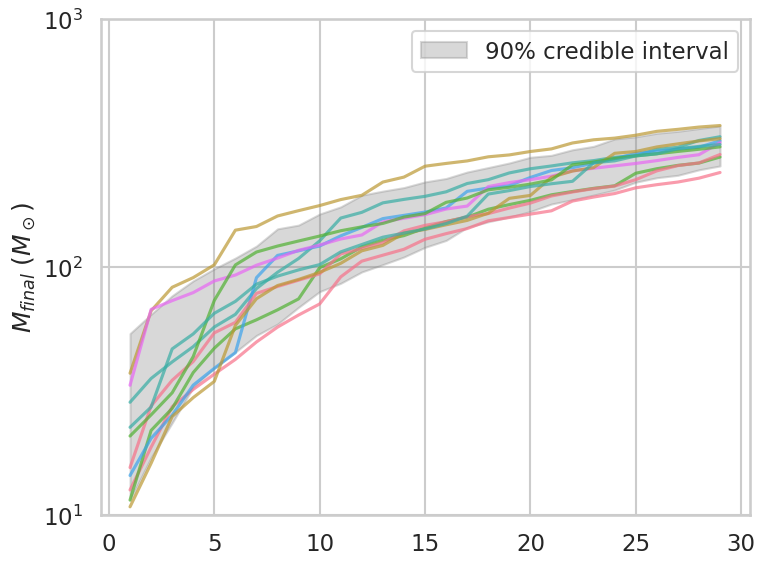

In [7]:
plt.figure(figsize=(8,6))

for i in sample_idxs:
    plt.plot(mergers[i]["Ng"], mergers[i]["m_f"], alpha=0.7)

plt.fill_between(all_Ng, lower, upper, color='gray', alpha=0.3, label='90% credible interval')

plt.yscale('log')
plt.ylabel(r'$M_{final}$ ($M_\odot$)')
plt.ylim(1e1,1e3)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [9]:
mergers[0]

,mass_1,mass_2,a_1,a_2,tilt_1,tilt_2,Ng,m_f,a_f,v_k
0,47.854709,6.618914,0.008040,0.041415,1.112315,2.866163,1,53.802007,0.330519,92.749175
1,53.802007,7.145131,0.330519,0.027097,2.243569,0.789545,2,60.344703,0.261814,140.833582
2,60.344703,5.458381,0.261814,0.006771,1.130765,0.688375,3,65.255943,0.380825,78.056726
3,65.255943,9.918737,0.380825,0.037668,2.398265,1.397447,4,74.353365,0.248018,148.779336
4,74.353365,6.421512,0.248018,0.097590,2.380450,2.079857,5,80.281302,0.166123,67.982810
5,80.281302,21.991690,0.166123,0.044881,1.294245,1.037089,6,99.601559,0.525426,275.325619
6,99.601559,13.235237,0.525426,0.084452,1.135703,1.610505,7,111.200877,0.598446,314.673135
7,111.200877,13.527634,0.598446,0.080041,1.693657,2.090991,8,123.488753,0.525845,278.505806
8,123.488753,8.362117,0.525845,0.097255,2.809328,0.787648,9,131.339786,0.269652,45.077176
9,131.339786,35.475678,0.269652,0.028084,2.622519,2.311931,10,163.352320,0.380295,193.046739


## Method 2: By populations

In [8]:
N_initial = 30
N_branches = 100
branch = {}

In [30]:
for i in range(N_branches):
    branch[i] = functions.create_ng1g_chain(priors, int(N_initial))

In [31]:
branch_N_merge = {}
branch_mass = {}
branch_spin = {}
branch_kick = {}

for i, pops in branch.items():
    branch_N_merge[i] = []
    branch_mass[i] = []
    branch_spin[i] = []
    branch_kick[i] = []
    for df in pops.values():
        branch_N_merge[i].append(df["N_merge"].iloc[-1])
        branch_mass[i].append(df["mass_1"].iloc[-1])
        branch_spin[i].append(df["a_1"].iloc[-1])
        branch_kick[i].append(df["kick"].iloc[-1])

In [32]:
# pick 3 random branches (or any 3 you want)
sample_branches = np.random.choice(list(branch.keys()), size=10, replace=False)

In [33]:
# create a common N_merge grid (assuming integer values)
all_N = sorted(set(np.concatenate([branch_N_merge[i] for i in branch])))

# collect all masses per N_merge across all branches
mass_matrix = []
spin_matrix = []
for N in all_N:
    masses_at_N = [
        branch_mass[i][np.where(np.array(branch_N_merge[i]) == N)[0][0]]
        for i in branch
        if N in branch_N_merge[i]
    ]
    mass_matrix.append(masses_at_N)

# compute 5th and 95th percentiles for the 90% credible interval
lower = [np.percentile(m, 5) if len(m) > 0 else np.nan for m in mass_matrix]
upper = [np.percentile(m, 95) if len(m) > 0 else np.nan for m in mass_matrix]
median = [np.median(m) if len(m) > 0 else np.nan for m in mass_matrix]

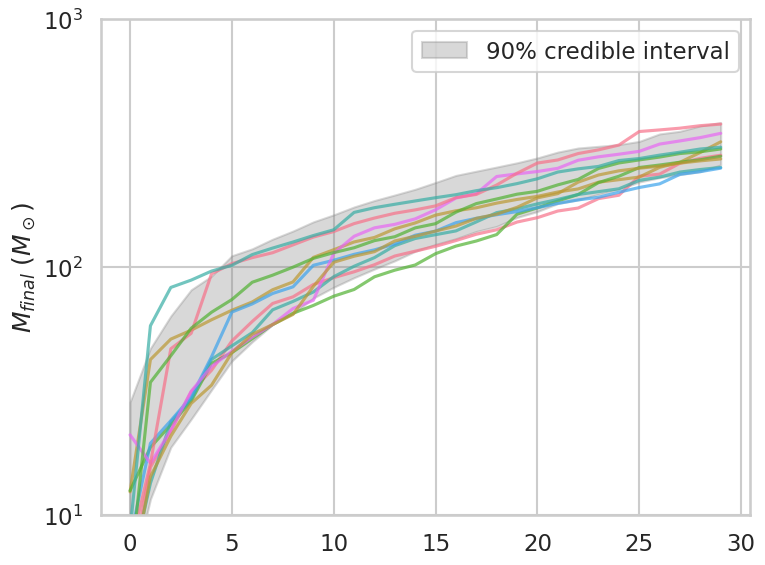

In [36]:
plt.figure(figsize=(8,6))

for i in sample_branches:
    plt.plot(branch_N_merge[i], branch_mass[i], alpha=0.7)

plt.fill_between(all_N, lower, upper, color='gray', alpha=0.3, label='90% credible interval')

plt.yscale('log')
plt.ylabel(r'$M_{final}$ ($M_\odot$)')
plt.ylim(1e1,1e3)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()